In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pygeostat as gs
import seaborn as sns


In [ ]:
gs.PlotStyle['font.size'] = 18
color_perm = 'darkorange'
color_poro = 'olive'
pallet_sp = 'seismic'
path = '18-JPEG/'


# Importing Dataset

In [ ]:
data = gs.DataFile(flname='01-Data\Set1_wells.prn', x='X', y='Y', z='Z', tmin=-98) 
df = data.data


In [ ]:
path_import = '19-etype'

etype_fda_sgsim_poro = pd.read_csv(f'{path_import}/etype_fda-sgsim_poro.csv')
etype_fda_sgsim_perm = pd.read_csv(f'{path_import}/etype_fda-sgsim_perm.csv')
etype_ppmt_fda_sgsim_perm = pd.read_csv(f'{path_import}/etype_ppmt-fpca-sgsim_perm.csv')
etype_ppmt_fda_sgsim_poro = pd.read_csv(f'{path_import}/etype_ppmt-fpca-sgsim_poro.csv')
etype_sgsim_perm = pd.read_csv(f'{path_import}/etype_sgsim_perm.csv')
etype_sgsim_poro = pd.read_csv(f'{path_import}/etype_sgsim_poro.csv')
sgsim_perm_real1 = pd.read_csv(f'{path_import}/sgsim_perm_real1.csv')
sgsim_poro_real1 = pd.read_csv(f'{path_import}/sgsim_poro_real1.csv')


In [5]:
fda_sgsim_perm_real1 = gs.DataFile(flname=f'{path_import}/fda_sgsim_perm_real1.out')
fda_sgsim_poro_real1 = gs.DataFile(flname=f'{path_import}/fda_sgsim_poro_real1.out')
ppmt_fda_sgsim_real1 = gs.DataFile(flname=f'{path_import}/ppmt_fpca_sgsim_ppmt_b_real1.out')


In [ ]:
ppmt_fda_sgsim_real1.data


,PPMT_B:Simulate_Poro,PPMT_B:Simulate_Perm
0,0.217000,514.08266
1,0.212000,512.12841
2,0.214000,512.37371
3,0.209000,510.01580
4,0.209000,512.00603
...,...,...
907884,0.197000,674.92542
907885,0.196852,674.35818
907886,0.196000,665.60074
907887,0.198000,675.06478


In [ ]:
def sturges(df, column_name):
    n_samples = len(df[column_name])
    k = round(1 + 3.322 * np.log10(n_samples))
    return k


In [ ]:
sturges(data, 'Perm')


11

In [ ]:
#gs.scatter_plot(data['Perm'], data['Poro'], grid=True, cmap='inferno', title='Scatter Plot\nPermeabilidade x Porosidade', cbar=True, stat_blk='all')


In [ ]:
grid_3d = gs.GridDef('''101   0.0    1.0               -nx,xmn,xsiz
101   0.0    1.0               -ny,ymn,ysiz
89    0.0    1.0               -nz,zmn,zsiz ''')


In [ ]:
df['wells'] = df.groupby(['X', 'Y']).ngroup()

data.data.head(3)


,X,Y,Z,Poro,Ip,Perm,wells
0,17.692,86.628,1.0,0.205,7843.205,504.594,2
1,17.692,86.628,2.0,0.205,7843.208,504.594,2
2,17.692,86.628,3.0,0.205,7843.213,504.594,2


In [ ]:
print(grid_3d.count())
print(sgsim_poro_real1.shape)
print(fda_sgsim_poro_real1.shape)
print(ppmt_fda_sgsim_real1.shape)


907889
(907889, 2)
(907889, 1)
(907889, 2)


# Vizual Validation Reals

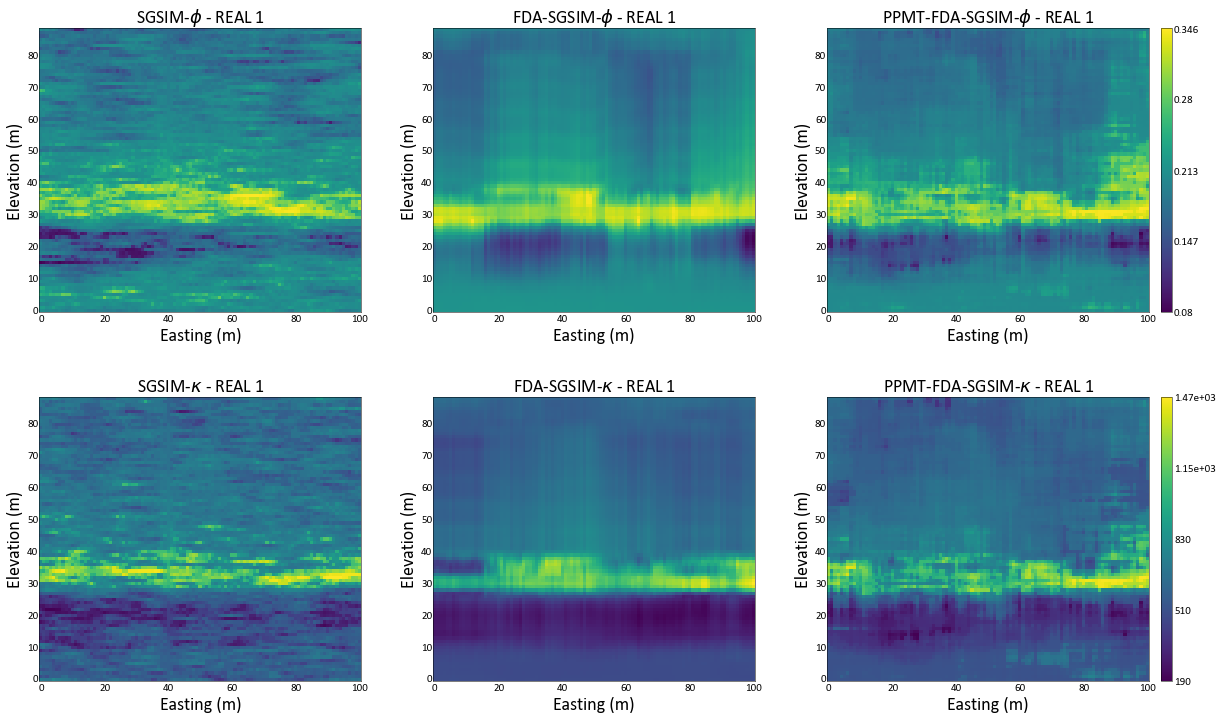

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

# Primeira linha - poro (inversão da ordem das linhas)
gs.slice_plot(sgsim_poro_real1, 
              var='Nscore_b:variable_001', 
              orient='xz', 
              title=f'SGSIM-$\phi$ - REAL 1',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[0,0],
             )
gs.slice_plot(fda_sgsim_poro_real1, 
              var='Simulate_Poro', 
              orient='xz', 
              title=f'FDA-SGSIM-$\phi$ - REAL 1',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[0,1],
             )
gs.slice_plot(ppmt_fda_sgsim_real1, 
              var='PPMT_B:Simulate_Poro', 
              orient='xz', 
              title=f'PPMT-FDA-SGSIM-$\phi$ - REAL 1',
              griddef=grid_3d,
              slice_number=61,
              ax=axes[0,2],
             )

# Segunda linha - perm (inversão da ordem das linhas)
gs.slice_plot(sgsim_perm_real1, 
              var='Nscore_b:variable_002', 
              orient='xz', 
              title=f'SGSIM-$\kappa$ - REAL 1',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[1,0],
             )
gs.slice_plot(fda_sgsim_perm_real1, 
              var='Simulate_Poro', 
              orient='xz', 
              title=f'FDA-SGSIM-$\kappa$ - REAL 1',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[1,1],
             )
gs.slice_plot(ppmt_fda_sgsim_real1, 
              var='PPMT_B:Simulate_Perm', 
              orient='xz', 
              title=f'PPMT-FDA-SGSIM-$\kappa$ - REAL 1',
              griddef=grid_3d,
              slice_number=61,
              ax=axes[1,2],
             )

# Ajuste dos espaços entre os subplots
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.savefig(f'{path}real1_validation_perm_poro_combined')
plt.show()


# Vizual Validation Reals

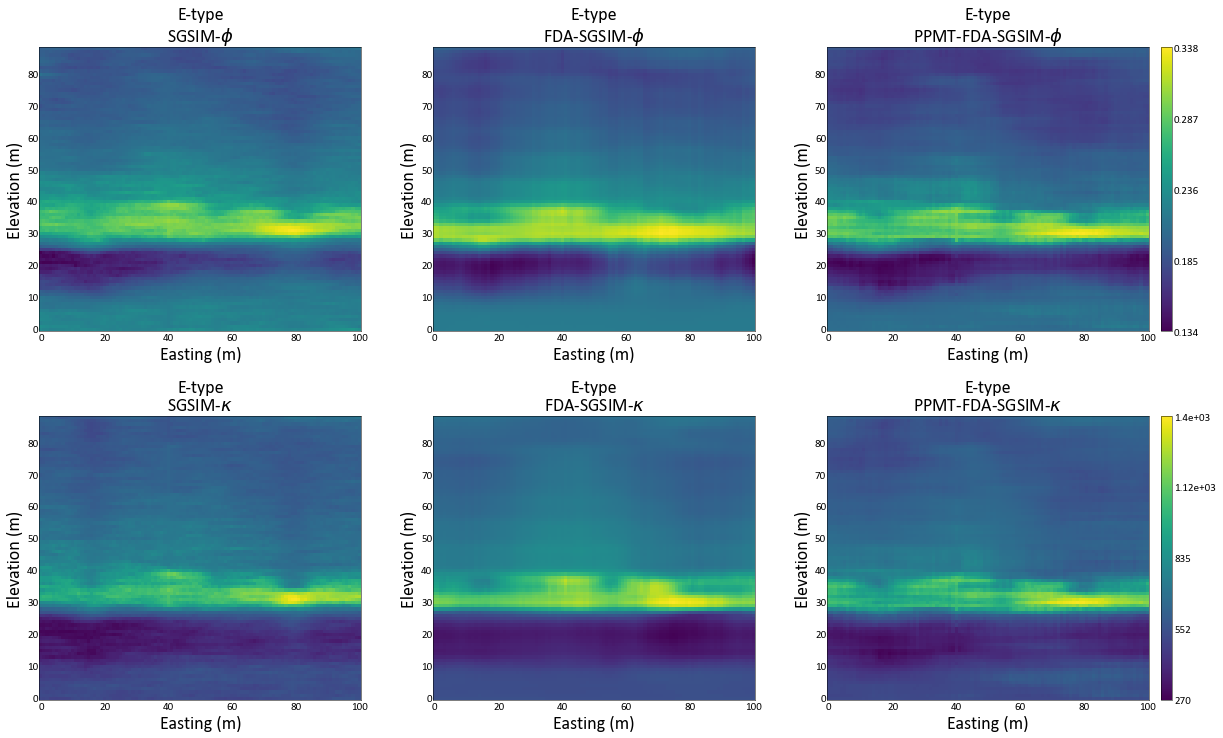

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

# Primeira linha - \phi
gs.slice_plot(etype_sgsim_poro, 
              var='0', 
              orient='xz', 
              title=f'E-type\nSGSIM-$\phi$',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[0,0],
             )
gs.slice_plot(etype_fda_sgsim_poro, 
              var='0', 
              orient='xz', 
              title=f'E-type\nFDA-SGSIM-$\phi$',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[0,1],
             )
gs.slice_plot(etype_ppmt_fda_sgsim_poro, 
              var='0', 
              orient='xz', 
              title=f'E-type\nPPMT-FDA-SGSIM-$\phi$',
              griddef=grid_3d,
              slice_number=61,
              ax=axes[0,2],
             )

# Segunda linha - \(\kappa\)
gs.slice_plot(etype_sgsim_perm, 
              var='0', 
              orient='xz', 
              title=f'E-type\nSGSIM-$\kappa$',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[1,0],
             )
gs.slice_plot(etype_fda_sgsim_perm, 
              var='0', 
              orient='xz', 
              title=f'E-type\nFDA-SGSIM-$\kappa$',
              griddef=grid_3d,
              slice_number=61,
              cbar=False,
              ax=axes[1,1],
             )
gs.slice_plot(etype_ppmt_fda_sgsim_perm, 
              var='0', 
              orient='xz', 
              title=f'E-type\nPPMT-FDA-SGSIM-$\kappa$',
              griddef=grid_3d,
              slice_number=61,
              ax=axes[1,2],
             )

# Ajuste dos espaços entre os subplots
plt.subplots_adjust(wspace=0.2, hspace=0.3)
plt.savefig(f'{path}etype_validation_combined')
plt.show()


# Bivariate Validation

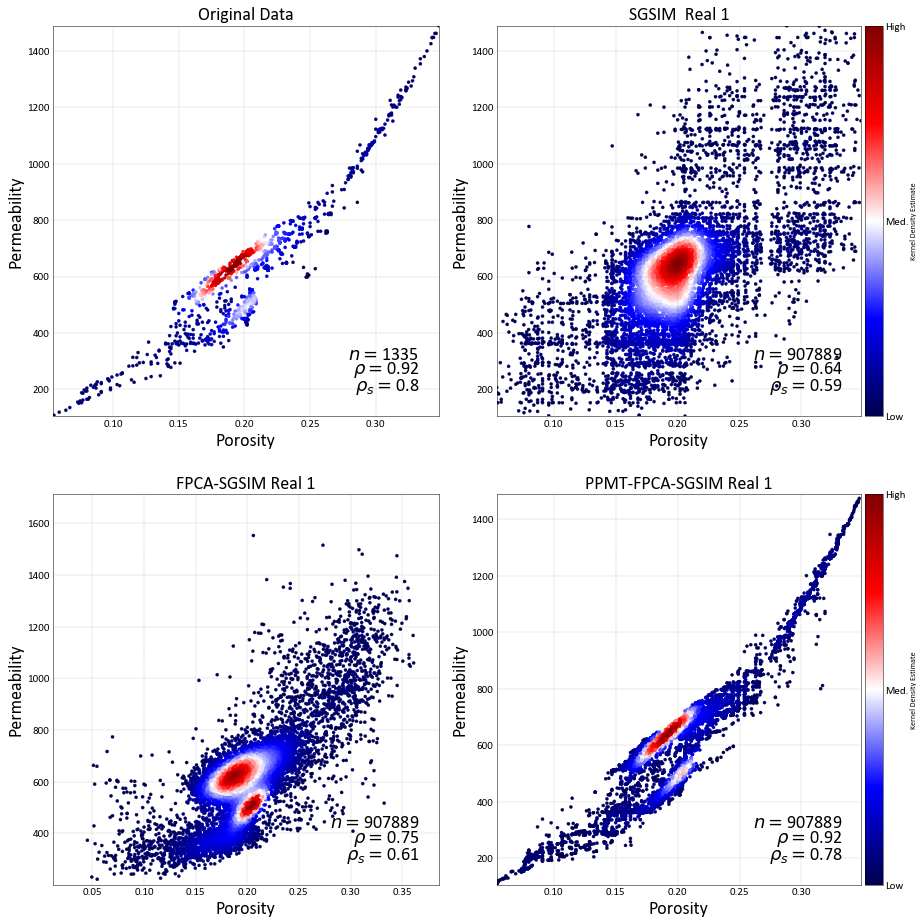

In [ ]:
s = 10

fig, axes = plt.subplots(2, 2, figsize=(13, 13))

gs.scatter_plot(data['Poro'], data['Perm'], 
                grid=True, 
                cmap='seismic', 
                title='Original Data', 
                stat_blk='all',
                xlabel='Porosity',
                ylabel='Permeability',
                s=s,
                ax=axes[0, 0]
               )

gs.scatter_plot(sgsim_poro_real1['Nscore_b:variable_001'], 
                sgsim_perm_real1['Nscore_b:variable_002'], 
                grid=True, 
                cmap='seismic', 
                title='SGSIM  Real 1',
                cbar=True, 
                stat_blk='all',
                xlabel='Porosity',
                ylabel='Permeability',
                ax=axes[0, 1],
                nmax=10000,
                s=s,
               )

gs.scatter_plot(fda_sgsim_poro_real1['Simulate_Poro'], 
                fda_sgsim_perm_real1['Simulate_Poro'], 
                grid=True, 
                cmap='seismic', 
                title='FPCA-SGSIM Real 1',
                stat_blk='all',
                xlabel='Porosity',
                ylabel='Permeability',
                ax=axes[1, 0],
                nmax=10000,
                s=s,
               )

gs.scatter_plot(ppmt_fda_sgsim_real1['PPMT_B:Simulate_Poro'], 
                ppmt_fda_sgsim_real1['PPMT_B:Simulate_Perm'], 
                grid=True, 
                cmap='seismic', 
                title='PPMT-FPCA-SGSIM Real 1',
                cbar=True, 
                stat_blk='all',
                xlabel='Porosity',
                ylabel='Permeability',
                ax=axes[1, 1],
                nmax=10000,
                s=s,
               )

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.subplots_adjust(hspace=0.2)
plt.savefig(f'{path}scatterplot_validation_final')
plt.show()


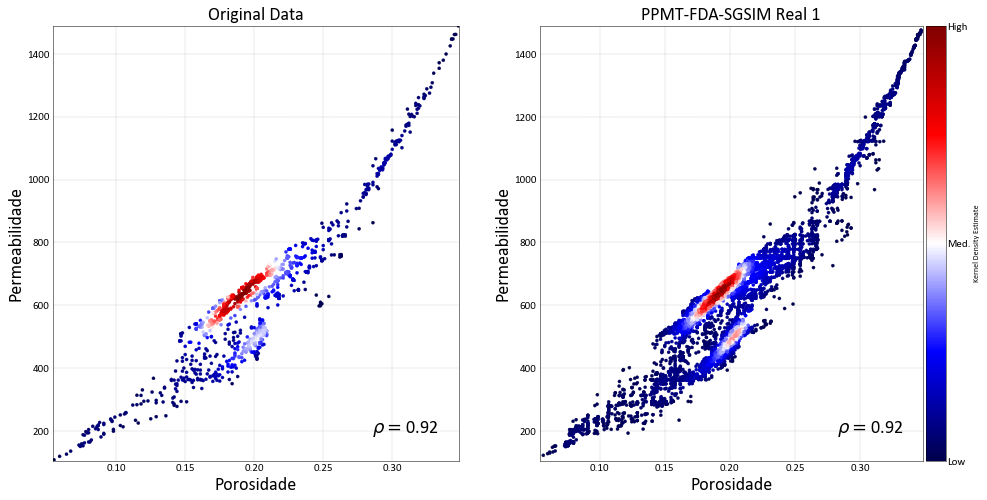

In [ ]:
s=10

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

gs.scatter_plot(data['Poro'], data['Perm'], 
                grid=True, 
                cmap=pallet_sp, 
                title='Original Data', 
                #cbar=True, 
                #stat_blk='all',
                xlabel='Porosidade',
                ylabel='Permeabilidade',
                s=s,
                ax=axes[0]
               )

gs.scatter_plot(ppmt_fda_sgsim_real1['PPMT_B:Simulate_Poro'], 
                ppmt_fda_sgsim_real1['PPMT_B:Simulate_Perm'], 
                grid=True, 
                cmap=pallet_sp, 
                title='PPMT-FDA-SGSIM Real 1',
                cbar=True, 
                #stat_blk='all',
                xlabel='Porosidade',
                ylabel='Permeabilidade',
                ax=axes[1],
                nmax=10000,
                s=s,
               )

#plt.tight_layout()
#plt.subplots_adjust(wspace=0.15)
#plt.subplots_adjust(hspace=0.2)
plt.savefig(f'{path}scatterplot_validation_final_valid')
plt.show()


<AxesSubplot:title={'center':'Scatter Plot - Real 1\nFDA-SGSIM'}, xlabel='Porosidade', ylabel='Permeabilidade'>

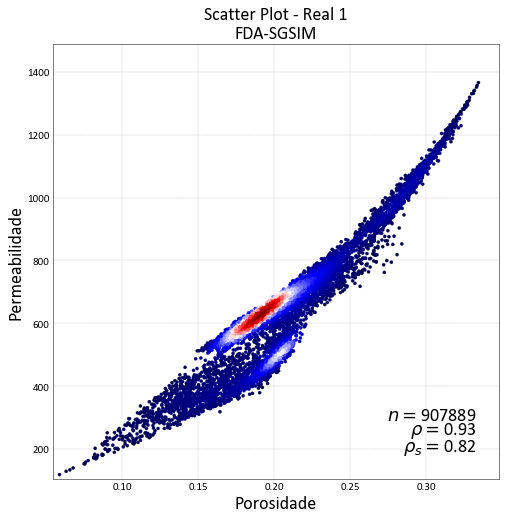

In [ ]:
gs.scatter_plot(etype_ppmt_fda_sgsim_poro['0'], 
                etype_ppmt_fda_sgsim_perm['0'], 
                grid=True, 
                cmap=pallet_sp, 
                title='Scatter Plot - Real 1\nFDA-SGSIM',
                #cbar=True, 
                stat_blk='all',
                xlabel='Porosidade',
                ylabel='Permeabilidade',
                nmax=10000,
                s=s,
               )


# SGSIM SCATTER PLOTS

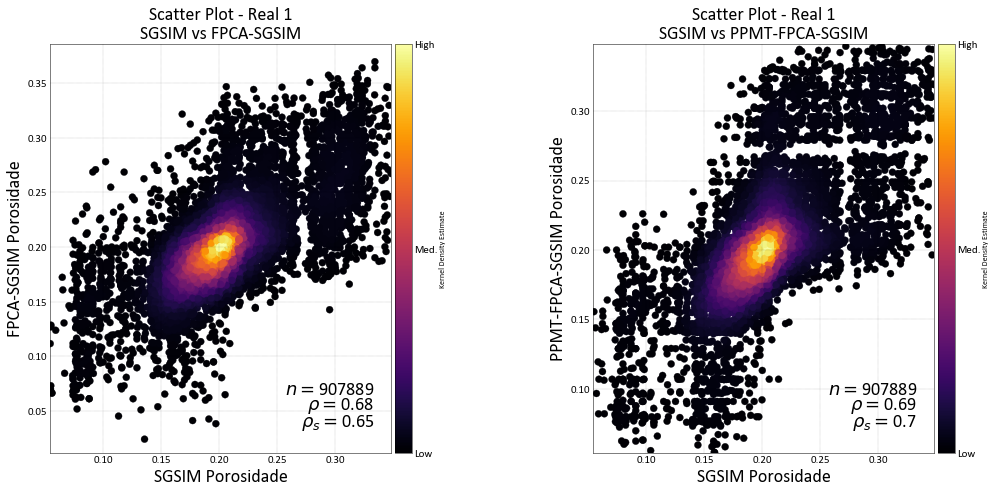

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

gs.scatter_plot(sgsim_poro_real1['Nscore_b:variable_001'], 
                fda_sgsim_poro_real1['Simulate_Poro'], 
                grid=True, 
                cmap='inferno', 
                title='Scatter Plot - Real 1\nSGSIM vs FPCA-SGSIM',
                cbar=True, 
                stat_blk='all',
                xlabel = 'SGSIM Porosidade',
                ylabel= 'FPCA-SGSIM Porosidade',
                ax=axes[0],
                nmax=10000,
               )

gs.scatter_plot(sgsim_poro_real1['Nscore_b:variable_001'], 
                ppmt_fda_sgsim_real1['PPMT_B:Simulate_Poro'], 
                grid=True, 
                cmap='inferno', 
                title='Scatter Plot - Real 1\nSGSIM vs PPMT-FPCA-SGSIM',
                cbar=True, 
                stat_blk='all',
                xlabel = 'SGSIM Porosidade',
                ylabel= 'PPMT-FPCA-SGSIM Porosidade',
                ax=axes[1],
                nmax=10000
               )
                                     
plt.tight_layout()
plt.subplots_adjust(wspace=0.5)
#plt.savefig(f'{path}scatterplot_validation')
plt.show()                                      


# SWP REAL 1

In [ ]:
x, y, z = grid_3d.get_coordinates()

df = pd.concat([
    pd.DataFrame({'X': x}),
    pd.DataFrame({'Y': y}),
    pd.DataFrame({'Z': z}),
    pd.DataFrame({'SGSIM': sgsim_poro_real1['Nscore_b:variable_001']}),
    pd.DataFrame({'FPCA-SGSIM': fda_sgsim_poro_real1['Simulate_Poro']}),
    pd.DataFrame({'PPMT-FPCA-SGSIM': ppmt_fda_sgsim_real1['PPMT_B:Simulate_Poro']})
], axis=1)


In [ ]:
df


,X,Y,Z,SGSIM,FPCA-SGSIM,PPMT-FPCA-SGSIM
0,0.0,0.0,0.0,0.171000,0.206552,0.217000
1,1.0,0.0,0.0,0.162001,0.206452,0.212000
2,2.0,0.0,0.0,0.162728,0.205620,0.214000
3,3.0,0.0,0.0,0.171000,0.205632,0.209000
4,4.0,0.0,0.0,0.164001,0.205556,0.209000
...,...,...,...,...,...,...
907884,96.0,100.0,88.0,0.207001,0.177344,0.197000
907885,97.0,100.0,88.0,0.205001,0.179944,0.196852
907886,98.0,100.0,88.0,0.202001,0.177420,0.196000
907887,99.0,100.0,88.0,0.202001,0.173015,0.198000


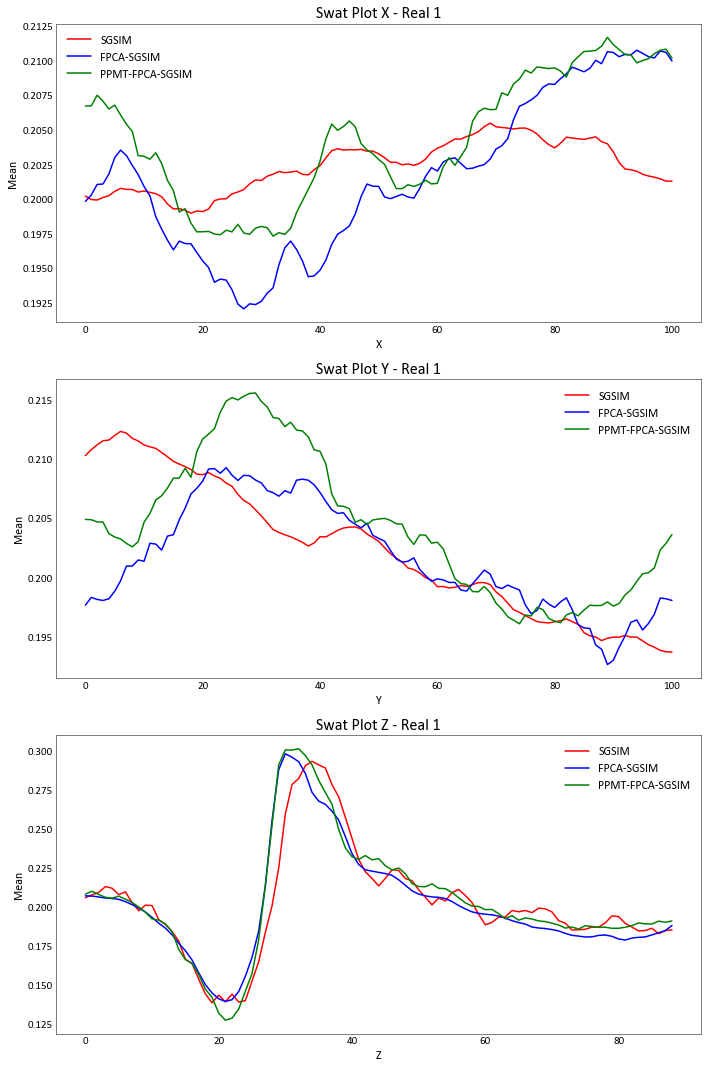

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

colors = ['red', 'blue', 'green']

df.groupby('X')[['SGSIM', 'FPCA-SGSIM', 'PPMT-FPCA-SGSIM']].mean().plot(ax=axes[0], color=colors)
axes[0].set_title('Swat Plot X - Real 1', fontsize=16)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Mean', fontsize=12)
axes[0].legend(fontsize=12)

df.groupby('Y')[['SGSIM', 'FPCA-SGSIM', 'PPMT-FPCA-SGSIM']].mean().plot(ax=axes[1], color=colors)
axes[1].set_title('Swat Plot Y - Real 1', fontsize=16)
axes[1].set_xlabel('Y', fontsize=12)
axes[1].set_ylabel('Mean', fontsize=12)
axes[1].legend(fontsize=12)

df.groupby('Z')[['SGSIM', 'FPCA-SGSIM', 'PPMT-FPCA-SGSIM']].mean().plot(ax=axes[2], color=colors)
axes[2].set_title('Swat Plot Z - Real 1', fontsize=16)
axes[2].set_xlabel('Z', fontsize=12)
axes[2].set_ylabel('Mean', fontsize=12)
axes[2].legend(fontsize=12)

plt.tight_layout()
plt.show()


# SWP E-TYPE

In [ ]:
from sklearn import neighbors

# KNN parameters. For k=1, we have the classic estimator 'nearest neighbor'

K = 1	# number of neighbors
P = 'distance'	# distance weight function, atribute already implemented on the algorithm 'KNeighborsRegressor'

# Dataset
x_ds=data['X'].values 
y_ds=data['Y'].values 
z_ds=data['Z'].values 
poro_ds=data['Poro'].values 

xy_ds=np.stack((x_ds,y_ds,z_ds)).T # transpose as [[x1,y1],[x2,y2],...]

# Grid 
x, y, z = grid_3d.get_coordinates()
grid_knn = pd.concat([pd.DataFrame({'X': x}), pd.DataFrame({'Y': y}), pd.DataFrame({'Z': z})], axis=1)

x_g=grid_knn['X'].values
y_g=grid_knn['Y'].values
z_g=grid_knn['Z'].values

xy_grid=np.stack((x_g,y_g,z_g)).T # transpose as [[x1,y1],[x2,y2],...]

# Running KNN
clf = neighbors.KNeighborsRegressor(K, weights=P) # clf is the classifier
clf.fit(xy_ds, poro_ds) 
grid_knn['KNN_Poro'] = clf.predict(xy_grid)


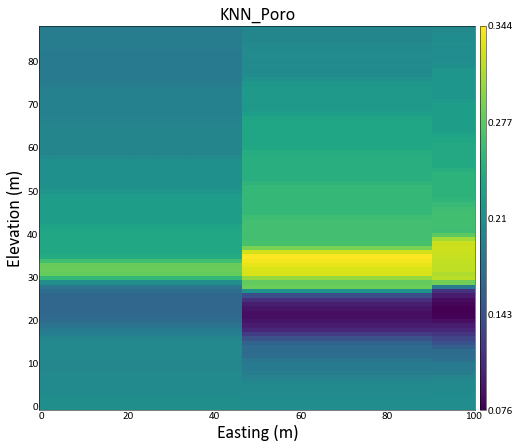

In [ ]:
_ = gs.slice_plot(grid_knn, var='KNN_Poro', griddef=grid_3d, cmap='viridis', orient='xz')


In [ ]:
df_etype = pd.concat([
    pd.DataFrame({'X': x}),
    pd.DataFrame({'Y': y}),
    pd.DataFrame({'Z': z}),
    pd.DataFrame({'SGSIM': etype_sgsim_poro['0']}),
    pd.DataFrame({'FDA-SGSIM': etype_fda_sgsim_poro['0']}),
    pd.DataFrame({'PPMT-FDA-SGSIM': etype_ppmt_fda_sgsim_poro['0']})],
    axis=1)


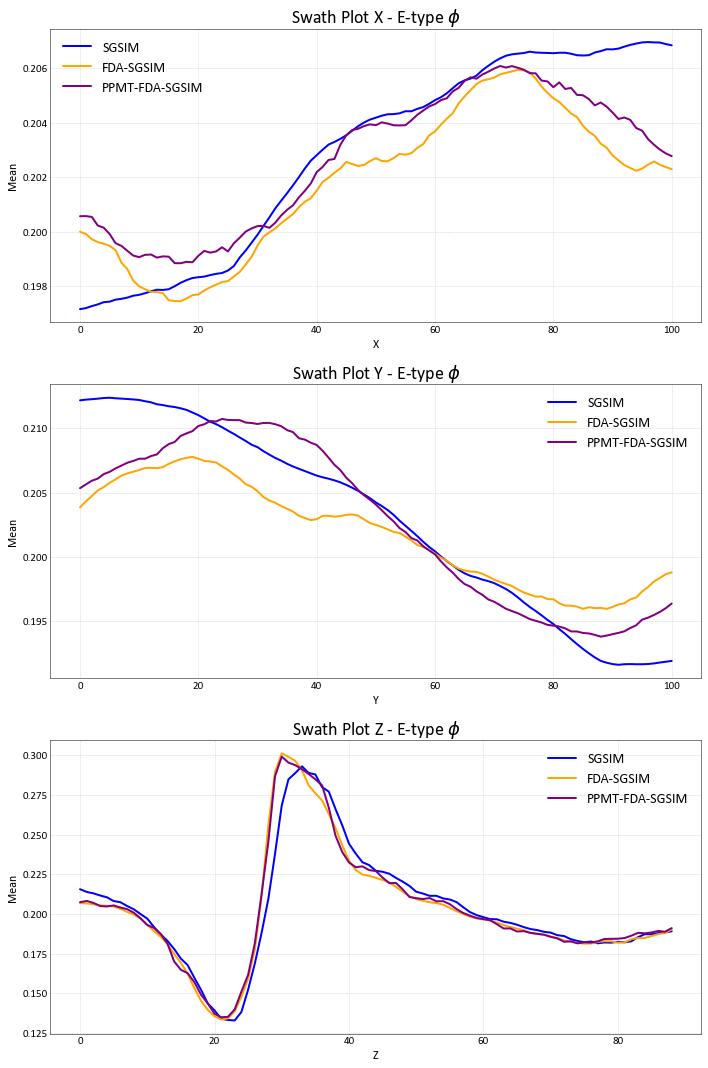

In [ ]:
colors = ['blue', 'orange', 'purple']
line_width = 2

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))

def add_grid(ax):
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='lightgrey')

df_etype.groupby('X')[['SGSIM', 'FDA-SGSIM', 'PPMT-FDA-SGSIM']].mean().plot(ax=axes[0], color=colors, linewidth=line_width)
axes[0].set_title('Swath Plot X - E-type $\phi$', fontsize=18)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Mean', fontsize=12)
axes[0].legend(fontsize=14)
add_grid(axes[0])

df_etype.groupby('Y')[['SGSIM', 'FDA-SGSIM', 'PPMT-FDA-SGSIM']].mean().plot(ax=axes[1], color=colors, linewidth=line_width)
axes[1].set_title('Swath Plot Y - E-type $\phi$', fontsize=18)
axes[1].set_xlabel('Y', fontsize=12)
axes[1].set_ylabel('Mean', fontsize=12)
axes[1].legend(fontsize=14)
add_grid(axes[1])

df_etype.groupby('Z')[['SGSIM', 'FDA-SGSIM', 'PPMT-FDA-SGSIM']].mean().plot(ax=axes[2], color=colors, linewidth=line_width)
axes[2].set_title('Swath Plot Z - E-type $\phi$', fontsize=18)
axes[2].set_xlabel('Z', fontsize=12)
axes[2].set_ylabel('Mean', fontsize=12)
axes[2].legend(fontsize=14)
add_grid(axes[2])

plt.tight_layout()
plt.savefig(f'{path}SWP_etype')
plt.show()


In [ ]:
import os

num_processors = os.cpu_count()
print(f"Número de processadores: {num_processors}")


Número de processadores: 16


In [ ]:
gs.scatter_plot(df_etype['Simulate_Poro'], 
                df_etype['Simulate_Poro'], 
                grid=True, 
                cmap=pallet_sp, 
                title='Scatter Plot - Real 1\nFDA-SGSIM',
                #cbar=True, 
                stat_blk='all',
                xlabel='Porosidade',
                ylabel='Permeabilidade',
                ax=axes[1, 0],
                nmax=10000,
                s=s,
               )


KeyError: 'Simulate_Poro'